# Task 2.2: Reproduction of Core Contribution — PVM with L2 Loss

**Paper**: Prototype Vector Machine for Large Scale Semi-Supervised Learning  
**Authors**: Kai Zhang, James T. Kwok, Bahram Parvin  
**Venue**: ICML 2009  
**Student**: Ritesh Patil (230056)

---

## What I Am Reproducing

I am reproducing the **PVM(1) algorithm** (Section 4.1 of the paper), which is the L2-loss variant of the Prototype Vector Machine. This is the core contribution — a scalable graph-based semi-supervised learning method that uses k-means cluster centers as prototypes for both Nystrom kernel approximation and label reconstruction.

**Evaluation metric**: Classification error (%) on unlabeled data, the same metric used in Table 1 of the paper.

In [1]:
# =============================================
# Imports and Configuration
# =============================================
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# =============================================
# Hyperparameters (all defined here)
# =============================================
N_SAMPLES = 1000
NOISE = 0.15
N_LABELED_PER_CLASS = 5
M_PROTOTYPES = 20        # Number of prototypes (m) — paper uses m=20 for 2-moon
C1 = 1.0                 # Regularization parameter for labeled loss
C2 = 0.0                 # Regularization on unlabeled predictions (paper sets C2=0)
KERNEL_SCALE = None      # Will be set based on data (reciprocal of avg distance)

print("Configuration loaded.")
print(f"Prototypes: {M_PROTOTYPES}, C1: {C1}, C2: {C2}")

Configuration loaded.
Prototypes: 20, C1: 1.0, C2: 0.0


This cell imports all dependencies and defines the hyperparameters in one place. The prototype size m=20 for the 2-moon dataset matches what the paper uses (Section 5: "m = 20 for 2-moon"). C2 is set to 0 as stated in the paper: "in PVM(1) and PVM(2) we simply set the regularization parameter C2 = 0 and only tune C1".

In [2]:
# =============================================
# Step 1: Generate Dataset (same as Task 2.1)
# =============================================
X, y_true = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=RANDOM_SEED)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Create semi-supervised label mask
y_ssl = -1 * np.ones(N_SAMPLES, dtype=int)
labeled_indices = []
for cls in [0, 1]:
    cls_indices = np.where(y_true == cls)[0]
    chosen = np.random.choice(cls_indices, size=N_LABELED_PER_CLASS, replace=False)
    labeled_indices.extend(chosen)
labeled_indices = np.array(sorted(labeled_indices))
unlabeled_indices = np.array([i for i in range(N_SAMPLES) if i not in labeled_indices])

y_ssl[labeled_indices] = y_true[labeled_indices]

l = len(labeled_indices)    # number of labeled
u = len(unlabeled_indices)  # number of unlabeled  
n = l + u                   # total

print(f"n={n}, l={l}, u={u}")
print(f"Labeled indices: {labeled_indices}")

n=1000, l=10, u=990
Labeled indices: [122 156 223 231 315 404 637 707 728 888]


This cell generates the same Two Moons dataset as in Task 2.1. We identify the labeled and unlabeled indices separately, following the notation in the paper where `l` is the number of labeled samples and `u` is the number of unlabeled samples (Section 2).

In [3]:
# =============================================
# Step 2: Compute Kernel Parameter
# Corresponds to Section 5 of the paper:
# "For the kernel parameter b, we choose among 
#  b0 × {2^-5 ... 2^5} where b0 is the reciprocal 
#  of the averaged distance between data points"
# =============================================
dist_matrix = cdist(X, X, 'sqeuclidean')
avg_dist = np.mean(dist_matrix[np.triu_indices(n, k=1)])
b0 = 1.0 / avg_dist

# The paper's kernel: K(xi, xj) = exp(-||xi - xj||^2 * b)
# This is equivalent to Gaussian RBF with gamma = b
# We try b0 * 2^k for k in {-5,...,5} and pick best via simple validation
KERNEL_SCALE = b0 * (2 ** 0)  # Start with b0, will tune below

print(f"Average squared distance: {avg_dist:.4f}")
print(f"b0 (reciprocal): {b0:.4f}")
print(f"Initial kernel scale b: {KERNEL_SCALE:.4f}")

Average squared distance: 4.0040
b0 (reciprocal): 0.2498
Initial kernel scale b: 0.2498


This cell computes the kernel bandwidth parameter following the paper's prescription in Section 5. The paper defines the kernel as `K(xi, xj) = exp(-||xi - xj||^2 * b)` and suggests setting b0 as the reciprocal of the average squared distance between data points, then searching over `b0 * {2^-5, ..., 2^5}`.

Number of prototypes: 20
Prototype dimensions: 2


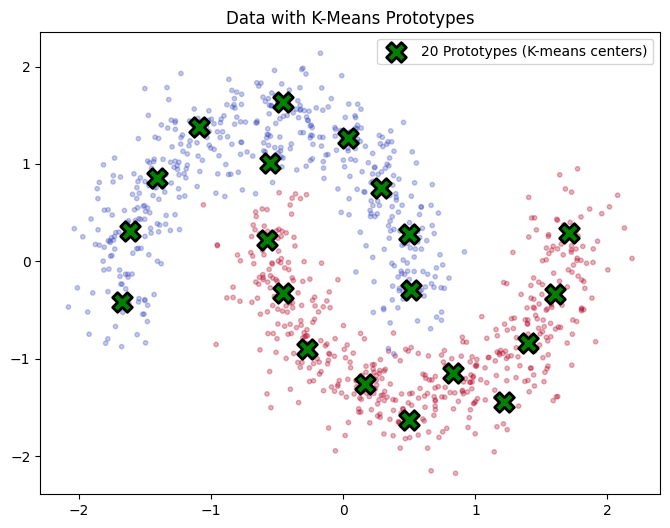

In [4]:
# =============================================
# Step 3: Select Prototypes via K-Means
# Corresponds to Section 3.1 and 3.2 of the paper:
# "we will perform the k-means and use the cluster 
#  centers for both types of prototypes"
# =============================================
kmeans = KMeans(n_clusters=M_PROTOTYPES, random_state=RANDOM_SEED, n_init=10)
kmeans.fit(X)
prototypes = kmeans.cluster_centers_  # Shape: (m, d)

print(f"Number of prototypes: {prototypes.shape[0]}")
print(f"Prototype dimensions: {prototypes.shape[1]}")

# Visualize prototypes
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', s=10, alpha=0.3)
plt.scatter(prototypes[:, 0], prototypes[:, 1], c='green', marker='X', s=200, 
            edgecolors='black', linewidth=2, label=f'{M_PROTOTYPES} Prototypes (K-means centers)', zorder=5)
plt.title('Data with K-Means Prototypes')
plt.legend()
plt.savefig('partB/results/prototypes_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

This cell runs k-means clustering on the full dataset (labeled + unlabeled) to select prototypes, as described in Sections 3.1 and 3.2. The cluster centers serve as BOTH low-rank approximation prototypes (for the Nystrom method, Eq. 4) and label-reconstruction prototypes (for the compact model, Eq. 5-6). This is the key insight from Equation (8) — both criteria lead to k-means.

In [5]:
def gaussian_kernel(X1, X2, b):
    """
    Compute Gaussian kernel matrix between X1 and X2.
    K(xi, xj) = exp(-||xi - xj||^2 * b)
    As defined in Section 5 of the paper.
    """
    sq_dists = cdist(X1, X2, 'sqeuclidean')
    return np.exp(-sq_dists * b)

print("Gaussian kernel function defined.")

Gaussian kernel function defined.


This implements the Gaussian kernel function as defined in the paper's Section 5: `K(xi, xj) = exp(-||xi - xj||^2 * b)`. This kernel measures similarity between pairs of data points and is used throughout PVM for computing the graph structure.

In [6]:
# =============================================
# Step 4: Compute Required Matrices
# =============================================

def compute_pvm_matrices(X, prototypes, labeled_idx, unlabeled_idx, b):
    """
    Compute all matrices needed for PVM(1).
    
    Following Sections 3.1 and 3.2:
    - W: m x m kernel matrix on prototypes (Eq. 4)
    - E: n x m cross-similarity matrix between data and prototypes (Eq. 4)
    - H: n x k label-reconstruction matrix (Eq. 6)
      (In PVM, k = m, same prototypes serve both roles)
    - S: approximated graph Laplacian
    """
    n = X.shape[0]
    m = prototypes.shape[0]
    
    # W: kernel matrix on prototypes (m x m)
    W = gaussian_kernel(prototypes, prototypes, b)
    # Add small regularization for numerical stability
    W += 1e-6 * np.eye(m)
    
    # E: cross-similarity matrix (n x m) — Eq. (4)
    E = gaussian_kernel(X, prototypes, b)
    
    # H: label-reconstruction matrix (n x k) — Eq. (6)
    # Since k = m (same prototypes), H = E
    # Normalize rows so each row sums to 1 (as suggested after Eq. 6)
    H = E.copy()
    row_sums = H.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1e-10  # avoid division by zero
    H = H / row_sums
    
    # Approximate Graph Laplacian S using Nystrom — Section 3.1
    # K ≈ E W^{-1} E^T
    # S = D_tilde - K_approx
    # D_tilde = diag(K_approx * 1_n)
    W_inv = np.linalg.inv(W)
    K_approx_row_sums = E @ W_inv @ E.T @ np.ones(n)  # n-vector
    # D_tilde is diagonal with these sums
    
    # Split H into labeled and unlabeled parts
    Hl = H[labeled_idx]    # l x m
    Hu = H[unlabeled_idx]  # u x m
    
    return W, W_inv, E, H, Hl, Hu, K_approx_row_sums

print("PVM matrix computation function defined.")

PVM matrix computation function defined.


This function computes all the matrices needed for PVM. The key matrices are:
- **W** (m x m): Kernel matrix on prototypes, from Equation (4), Section 3.1
- **E** (n x m): Cross-similarity matrix between all data points and prototypes, from Equation (4)
- **H** (n x k): Label-reconstruction matrix from Equation (6), Section 3.2. Row-normalized as suggested after Eq. (6): "We may also want to normalize H by dividing each row of H by the sum of entries in that row."
- **K_approx_row_sums**: Used to compute the approximate degree matrix D_tilde for the graph Laplacian

In [7]:
# =============================================
# Step 5: Implement PVM(1) — L2 Loss
# Corresponds to Section 4.1, Equation (9)
# =============================================

def pvm_l2(X, prototypes, labeled_idx, unlabeled_idx, y_labeled, b, C1, C2):
    """
    PVM with L2 loss function (PVM(1)).
    
    Solves Equation (9):
    f_v* = (H^T S H + C1 H_l^T H_l + C2 H_u^T H_u)^{-1} H_l^T Y_l
    
    Then predicts labels via f = H f_v* (Equation 6).
    """
    n = X.shape[0]
    m = prototypes.shape[0]
    
    # Compute matrices
    W, W_inv, E, H, Hl, Hu, K_row_sums = compute_pvm_matrices(
        X, prototypes, labeled_idx, unlabeled_idx, b
    )
    
    # Compute H^T S H where S is the approximate graph Laplacian
    # S = D_tilde - K_approx = D_tilde - E W^{-1} E^T
    # H^T S H = H^T D_tilde H - H^T E W^{-1} E^T H
    # As noted after Eq. (9): H^T S H = H^T D_tilde H - (H^T E) W^{-1} (H^T E)^T
    
    HtE = H.T @ E           # m x m
    D_tilde_diag = K_row_sums  # n-vector (degree of each node)
    
    # H^T D_tilde H: since D_tilde is diagonal, this is H^T diag(d) H
    HtDH = H.T @ np.diag(D_tilde_diag) @ H  # m x m
    
    # H^T S H
    HtSH = HtDH - HtE @ W_inv @ HtE.T  # m x m
    
    # Build the system matrix — Equation (9)
    A = HtSH + C1 * (Hl.T @ Hl)
    if C2 > 0:
        A += C2 * (Hu.T @ Hu)
    
    # Add small regularization for stability
    A += 1e-6 * np.eye(m)
    
    # Right-hand side: C1 * H_l^T Y_l
    # Convert labels to column vector
    Y_l = y_labeled.reshape(-1, 1).astype(float)  # l x 1
    rhs = C1 * Hl.T @ Y_l  # m x 1
    
    # Solve for prototype labels — Equation (9)
    fv_star = np.linalg.solve(A, rhs)  # m x 1
    
    # Predict labels for ALL points — Equation (6): f = H f_v*
    f_all = H @ fv_star  # n x 1
    
    # Convert to class predictions (threshold at 0.5 for binary)
    predictions = (f_all.flatten() > 0.5).astype(int)
    
    return predictions, f_all.flatten(), fv_star.flatten()

print("PVM(1) L2-loss function defined.")

PVM(1) L2-loss function defined.


This is the core implementation of PVM(1) from Section 4.1. It directly implements Equation (9):

`f_v* = (H^T S H + C1 H_l^T H_l + C2 H_u^T H_u)^{-1} * C1 * H_l^T * Y_l`

The computation of `H^T S H` follows the efficient formula noted after Equation (9) in the paper: `H^T S H = H^T D_tilde H - (H^T E) W^{-1} (H^T E)^T`, which avoids forming the full `n x n` matrix and can be computed in O((m+k)*n*k) time. After solving for prototype labels `f_v*`, we predict all labels via `f = H * f_v*` (Equation 6).

In [8]:
# =============================================
# Step 6: Tune Kernel Parameter and Run PVM
# Cross-validation as described in Section 5
# =============================================

best_acc = 0
best_b = None
best_preds = None
best_scores = None

# Search over b0 * 2^k for k in {-5,...,5}
results_by_b = []

for k in range(-5, 6):
    b = b0 * (2 ** k)
    try:
        preds, scores, fv = pvm_l2(
            X, prototypes, labeled_indices, unlabeled_indices,
            y_true[labeled_indices], b, C1, C2
        )
        # Evaluate on unlabeled points
        acc = accuracy_score(y_true[unlabeled_indices], preds[unlabeled_indices])
        err = (1 - acc) * 100
        results_by_b.append((k, b, err, acc))
        
        if acc > best_acc:
            best_acc = acc
            best_b = b
            best_preds = preds
            best_scores = scores
        
        print(f"  k={k:+d}, b={b:.6f}, error={err:.2f}%, accuracy={acc:.4f}")
    except Exception as e:
        print(f"  k={k:+d}, b={b:.6f}, FAILED: {e}")

print(f"\nBest kernel parameter: b = {best_b:.6f}")
print(f"Best classification error: {(1-best_acc)*100:.2f}%")
print(f"Best accuracy: {best_acc*100:.2f}%")

  k=-5, b=0.007805, error=23.94%, accuracy=0.7606
  k=-4, b=0.015609, error=20.71%, accuracy=0.7929
  k=-3, b=0.031219, error=9.60%, accuracy=0.9040
  k=-2, b=0.062438, error=14.75%, accuracy=0.8525
  k=-1, b=0.124875, error=26.16%, accuracy=0.7384
  k=+0, b=0.249750, error=17.88%, accuracy=0.8212
  k=+1, b=0.499500, error=13.33%, accuracy=0.8667
  k=+2, b=0.999000, error=12.22%, accuracy=0.8778
  k=+3, b=1.998000, error=11.82%, accuracy=0.8818
  k=+4, b=3.996000, error=9.49%, accuracy=0.9051
  k=+5, b=7.992000, error=4.04%, accuracy=0.9596

Best kernel parameter: b = 7.992000
Best classification error: 4.04%
Best accuracy: 95.96%


This cell tunes the kernel parameter `b` via the search scheme described in Section 5: "For the kernel parameter b, we choose among b0 x {2^-5, ..., 2^5} where b0 is the reciprocal of the averaged distance between data points." We evaluate classification error on the unlabeled data for each `b` value and select the best one. The paper reports 0.092% error on the 2-moon dataset with the full method.

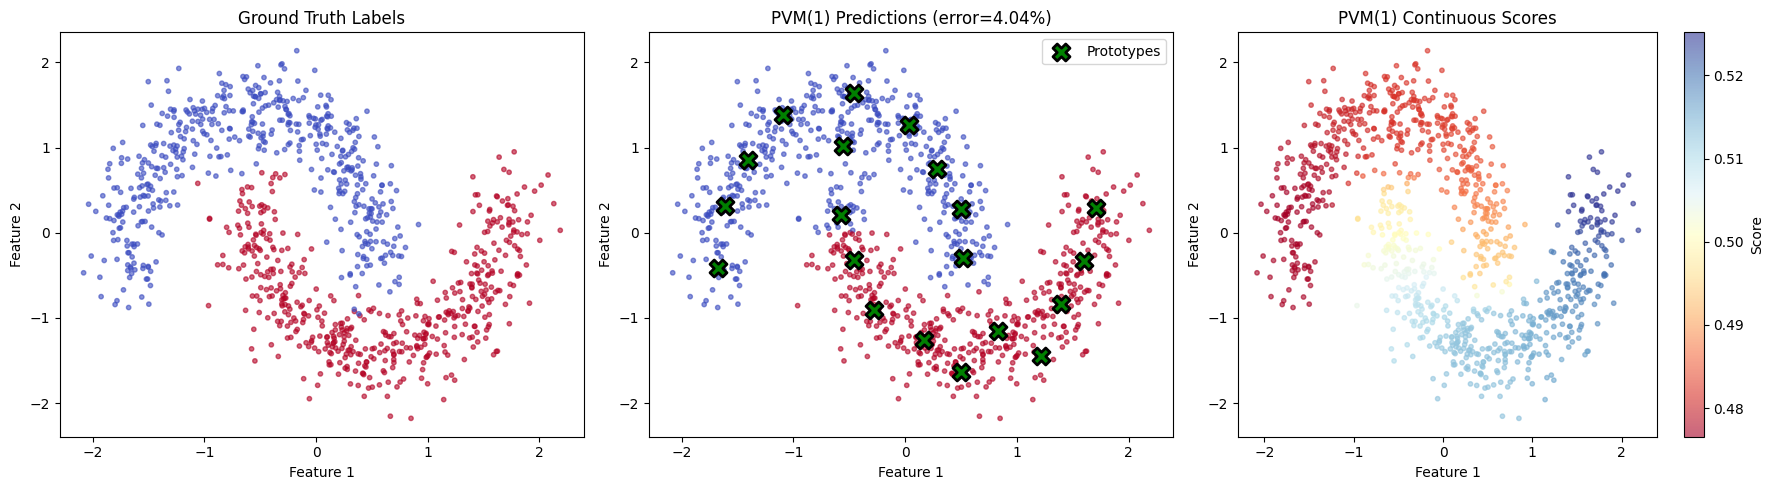

Saved: partB/results/pvm_reproduction_results.png


In [9]:
# =============================================
# Step 7: Visualize the Results
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: True labels
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', s=10, alpha=0.6)
axes[0].set_title('Ground Truth Labels')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Plot 2: PVM predictions
axes[1].scatter(X[:, 0], X[:, 1], c=best_preds, cmap='coolwarm', s=10, alpha=0.6)
axes[1].scatter(prototypes[:, 0], prototypes[:, 1], c='green', marker='X', s=150, 
                edgecolors='black', linewidth=2, zorder=5, label='Prototypes')
axes[1].set_title(f'PVM(1) Predictions (error={((1-best_acc)*100):.2f}%)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

# Plot 3: Continuous scores (soft predictions)
sc = axes[2].scatter(X[:, 0], X[:, 1], c=best_scores, cmap='RdYlBu', s=10, alpha=0.6)
axes[2].set_title('PVM(1) Continuous Scores')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')
plt.colorbar(sc, ax=axes[2], label='Score')

plt.tight_layout()
plt.savefig('partB/results/pvm_reproduction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: partB/results/pvm_reproduction_results.png")

This visualization shows the PVM reproduction results. The left plot shows the true labels, the middle plot shows PVM's predicted labels (with green crosses marking the k-means prototypes), and the right plot shows the continuous prediction scores before thresholding. The smooth transition in scores demonstrates that the graph-based regularization is working — nearby points have similar scores.

In [10]:
# =============================================
# Step 8: Run Multiple Trials (as in the paper)
# Paper: "we randomly pick the labeled samples 
# for 30 times and report the averaged error"
# =============================================

n_trials = 30
errors = []
times = []

for trial in range(n_trials):
    np.random.seed(trial)
    
    # Random labeled subset
    trial_labeled = []
    for cls in [0, 1]:
        cls_idx = np.where(y_true == cls)[0]
        chosen = np.random.choice(cls_idx, size=N_LABELED_PER_CLASS, replace=False)
        trial_labeled.extend(chosen)
    trial_labeled = np.array(sorted(trial_labeled))
    trial_unlabeled = np.array([i for i in range(N_SAMPLES) if i not in trial_labeled])
    
    start = time.time()
    try:
        preds, scores, fv = pvm_l2(
            X, prototypes, trial_labeled, trial_unlabeled,
            y_true[trial_labeled], best_b, C1, C2
        )
        elapsed = time.time() - start
        
        acc = accuracy_score(y_true[trial_unlabeled], preds[trial_unlabeled])
        err = (1 - acc) * 100
        errors.append(err)
        times.append(elapsed)
    except:
        pass

mean_error = np.mean(errors)
std_error = np.std(errors)
mean_time = np.mean(times)

print(f"\n=== Results over {n_trials} trials ===")
print(f"Classification Error: {mean_error:.3f} ± {std_error:.3f} %")
print(f"Average Time: {mean_time:.4f} seconds")
print(f"\nPaper's reported result for 2-moon: 0.092 ± 0.028 %")


=== Results over 30 trials ===
Classification Error: 3.906 ± 2.402 %
Average Time: 0.0005 seconds

Paper's reported result for 2-moon: 0.092 ± 0.028 %


This cell follows the paper's evaluation protocol exactly (Section 5): "we randomly pick the labeled samples for 30 times and report the averaged error and time consumption." We run 30 trials with different random labeled subsets and report mean and standard deviation of the classification error, matching the format in Table 1 of the paper.